In [1]:

# Import Libraries
import ast
import pandas as pd
from datasets import load_dataset
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter


# Load Dataset
dataset = load_dataset('Sumedchakma/jobs_record')
df = dataset['train'].to_pandas()


# Data Cleaning

# Convert job_posted_date to datetime
df['job_posted_date'] = pd.to_datetime(df['job_posted_date'])

# Convert job_skills from string to list
df['job_skills'] = df['job_skills'].apply(
    lambda x: ast.literal_eval(x) if pd.notna(x) else x
)

Repo card metadata block was not found. Setting CardData to empty.


# Seaborn intro

In [2]:
import seaborn as sns

In [3]:
# Only get data analyst jobs in the US
df_DA_US = df[(df['job_title_short'] == 'Data Analyst') & 
              (df['job_country'] == 'United States')].copy()



# drop Nan values from the salary year avg column for accurate visualization
df_DA_US = df_DA_US.dropna(subset =['salary_year_avg'])

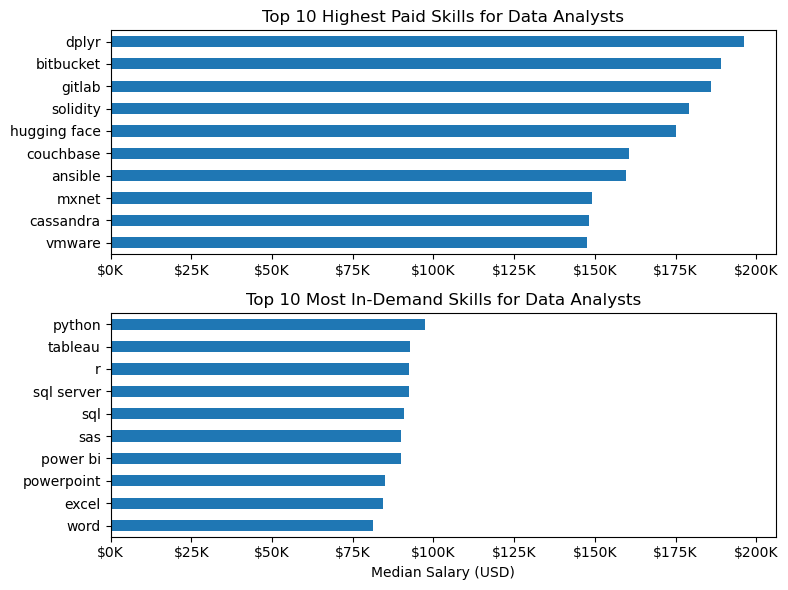

In [4]:
df_DA_US = df_DA_US.explode('job_skills')

df_DA_US[['salary_year_avg', 'job_skills']]


# Group by skill and calculate count & median salary
df_DA_US_group = (
    df_DA_US
    .groupby('job_skills')['salary_year_avg']
    .agg(['count', 'median'])
)

# Top 10 highest median paying skills
df_DA_top_pay = (
    df_DA_US_group
    .sort_values(by='median', ascending=False)
    .head(10)
)

# Top 10 most in-demand skills (by count), then sort them by median salary
df_DA_skills = (
    df_DA_US_group
    .sort_values(by='count', ascending=False)
    .head(10)
    .sort_values(by='median', ascending=False)
)

fig, ax = plt.subplots(2, 1, figsize=(8, 6))

# Top 10 Highest Paid Skills
df_DA_top_pay[::-1].plot(
    kind='barh',
    y='median',
    ax=ax[0],
    legend=False
)

ax[0].set_title('Top 10 Highest Paid Skills for Data Analysts')
ax[0].set_ylabel('')
ax[0].set_xlabel('')
ax[0].xaxis.set_major_formatter(
    plt.FuncFormatter(lambda x, pos: f'${int(x/1000)}K')
)


# Top 10 Most In-Demand Skills
df_DA_skills[::-1].plot(
    kind='barh',
    y='median',
    ax=ax[1],
    legend=False
)

ax[1].set_title('Top 10 Most In-Demand Skills for Data Analysts')
ax[1].set_ylabel('')
ax[1].set_xlabel('Median Salary (USD)')
ax[1].xaxis.set_major_formatter(
    plt.FuncFormatter(lambda x, pos: f'${int(x/1000)}K')
)

# Make both charts share same x-axis scale
ax[1].set_xlim(ax[0].get_xlim())

plt.tight_layout()
plt.show()


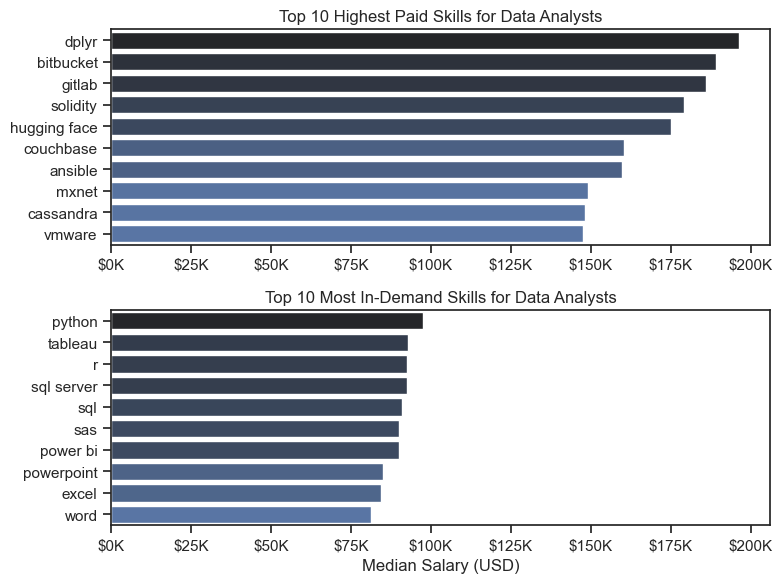

In [5]:
sns.set_theme(style="ticks")

fig, ax = plt.subplots(2, 1, figsize=(8, 6))

# Top 10 Highest Paid Skills
sns.barplot(
    data=df_DA_top_pay,
    x='median',
    y=df_DA_top_pay.index,
    ax=ax[0],
    hue='median',
    palette='dark:b_r',
    legend=False
)

ax[0].set_title('Top 10 Highest Paid Skills for Data Analysts')
ax[0].set_ylabel('')
ax[0].set_xlabel('')
ax[0].xaxis.set_major_formatter(
    plt.FuncFormatter(lambda x, _: f'${int(x/1000)}K')
)


# Top 10 Most In-Demand Skills
sns.barplot(
    data=df_DA_skills,
    x='median',
    y=df_DA_skills.index,
    ax=ax[1],
    hue='median',
    palette='dark:b_r',
    legend=False
)

ax[1].set_title('Top 10 Most In-Demand Skills for Data Analysts')
ax[1].set_ylabel('')
ax[1].set_xlabel('Median Salary (USD)')

# Make both plots share same x-axis scale
ax[1].set_xlim(ax[0].get_xlim())

ax[1].xaxis.set_major_formatter(
    plt.FuncFormatter(lambda x, _: f'${int(x/1000)}K')
)

plt.tight_layout()
plt.show()

## Histograms

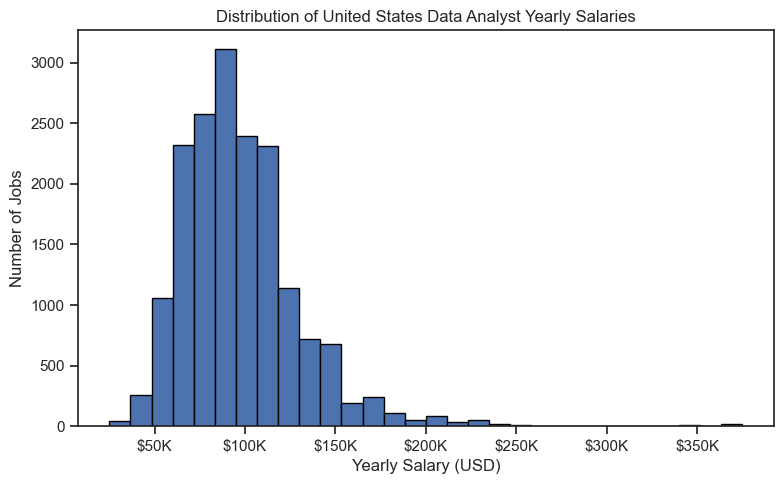

In [6]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick

# Create figure
plt.figure(figsize=(8, 5))

# Plot histogram
df_DA_US['salary_year_avg'].plot(
    kind='hist',
    bins=30,
    edgecolor='black'
)

# Titles and labels
plt.title('Distribution of United States Data Analyst Yearly Salaries')
plt.xlabel('Yearly Salary (USD)')
plt.ylabel('Number of Jobs')

# Format x-axis as $K
ax = plt.gca()
ax.xaxis.set_major_formatter(
    mtick.FuncFormatter(lambda x, pos: f'${int(x/1000)}K')
)

plt.tight_layout()
plt.show()

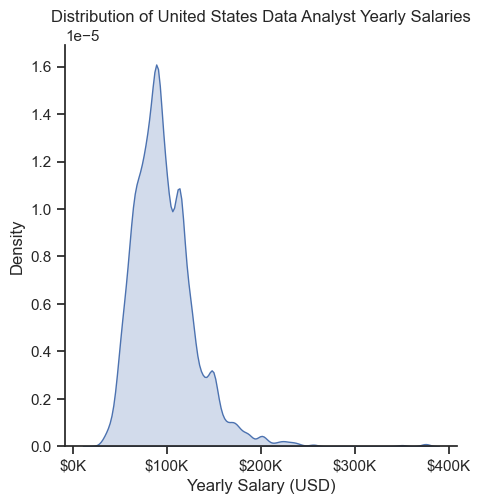

In [7]:
sns.set_theme(style="ticks")

sns.displot(df_DA_US['salary_year_avg'], kind='kde', fill=True)

plt.title('Distribution of United States Data Analyst Yearly Salaries')
plt.xlabel('Yearly Salary (USD)')
plt.ylabel('Density')   # KDE shows density, not number of jobs

ax = plt.gca()
ax.xaxis.set_major_formatter(
    plt.FuncFormatter(lambda x, pos: f'${int(x/1000)}K')
)

plt.show()

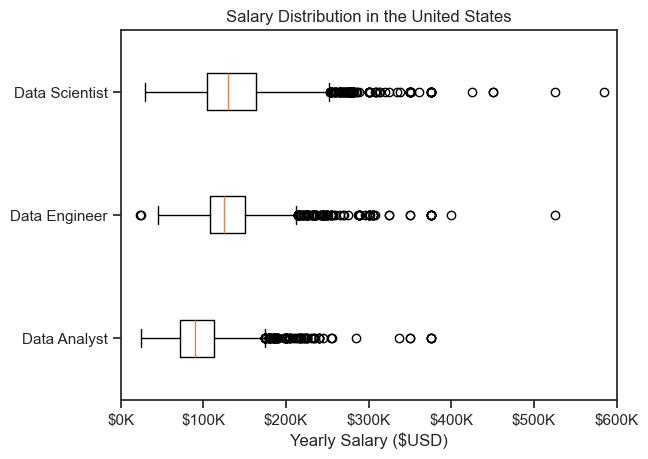

In [8]:
job_titles = ['Data Analyst', 'Data Engineer', 'Data Scientist']

# Filter the data to appropriate job_titles
df_US = df[
    (df['job_title_short'].isin(job_titles)) &
    (df['job_country'] == "United States")
].copy()

df_US = df_US.dropna(subset=['salary_year_avg'])

job_list = [
    df_US[df_US['job_title_short'] == job_title]['salary_year_avg']
    for job_title in job_titles
]

plt.boxplot(job_list, tick_labels=job_titles, vert=False)
plt.title('Salary Distribution in the United States')
plt.xlabel('Yearly Salary ($USD)')

ax = plt.gca()
ax.xaxis.set_major_formatter(
    plt.FuncFormatter(lambda x, pos: f'${int(x/1000)}K')
)

plt.xlim(0, 600000)
plt.show()

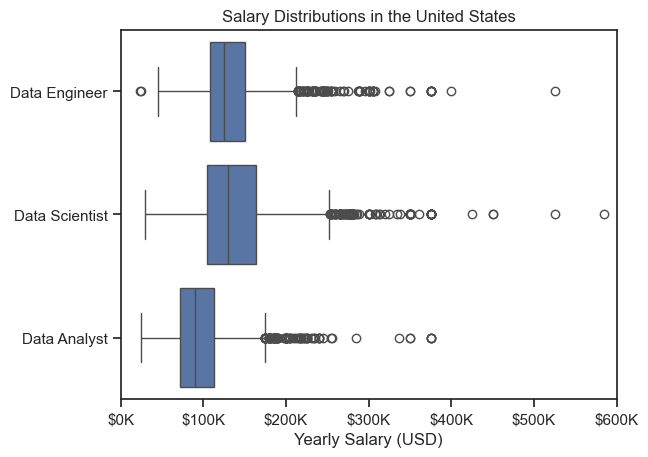

In [9]:
sns.boxplot(data=df_US, x='salary_year_avg', y='job_title_short')

plt.title('Salary Distributions in the United States')
plt.xlabel('Yearly Salary (USD)')
plt.ylabel('')

plt.xlim(0, 600000)

ax = plt.gca()

ticks_x = plt.FuncFormatter(lambda x, pos: f'${int(x/1000)}K')
ax.xaxis.set_major_formatter(ticks_x)

plt.show()